In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "C:/Users/dimit/Desktop/new/Modules")

In [2]:
from utils import *

In [3]:
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

In [13]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
years_to_remove = [year for year in range(2012, 2018)]
path = 'data/GR_Thessaly_WNV_Dataset_2010_2021.csv'

In [14]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,mosq_pred,mosq_previous,case
0,22.77356,39.67760,2010-01-01,θεσσαλιας,αγιας,22,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.74874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.267143,16.284286,8.25,11.242240,5.302469,9.587946,4.419169,16.775915,6.090496,19.523378,8.155853,22.057143,52.814286,0.0,295.000000,295.000000,295.000000,295.000000,295.000000,1,0,0
1,22.69493,39.10844,2010-01-01,θεσσαλιας,αλμυρου,6,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.21648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.082222,16.254444,11.91,9.896909,4.265526,10.677746,3.618618,17.039068,5.650136,20.541023,7.613520,13.700000,31.211111,0.3,260.444444,260.444444,260.444444,260.444444,260.444444,1,0,0
2,23.91189,39.20320,2010-01-01,θεσσαλιας,αλοννησου,24,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,45.92025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.640000,17.470000,11.81,12.687143,9.572857,11.814615,7.350000,14.911538,8.634000,17.832609,10.427500,62.200000,98.600000,0.0,323.000000,323.000000,323.000000,323.000000,323.000000,1,0,0
3,21.43052,39.25731,2010-01-01,θεσσαλιας,αργιθεας,0,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.72587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.565556,0.587778,5.773333,-1.428201,13.292222,2.807245,18.730554,6.231131,47.133333,88.466667,22.1,323.666667,323.666667,320.000000,320.000000,320.000000,1,0,0
4,22.93792,39.41186,2010-01-01,θεσσαλιας,βολου,14,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.60091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.356667,NaN,12.845119,5.105833,12.089515,3.862547,17.407709,6.368088,21.703833,8.805092,30.066667,48.733333,0.0,252.666667,252.666667,252.666667,252.666667,252.666667,1,0,0


In [15]:
dataset = dataset.query('month >= 5 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [16]:
dataset

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,mosq_pred,mosq_previous,case
0,22.77356,39.67760,2010-05-01,θεσσαλιας,αγιας,22,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,661.8,10705.0,17.3,45.74874,0.547381,0.237926,-0.263264,-0.237926,0.558343,0.227807,-0.292132,-0.227807,0.043105,0.042435,0.042110,0.042435,17.611429,22.981429,12.241429,11.242240,5.302469,9.587946,4.419169,16.775915,6.090496,19.523378,8.155853,2.400000,18.900000,209.271429,295.000000,295.000000,295.000000,295.000000,295.000000,14,30,0
1,22.69493,39.10844,2010-05-01,θεσσαλιας,αλμυρου,6,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,905.4,16004.0,20.6,45.21648,0.506245,0.188594,-0.291553,-0.188594,0.498612,0.179238,-0.298923,-0.179238,0.052604,0.050048,0.027790,0.050048,18.793333,25.723333,11.863333,9.896909,4.265526,10.677746,3.618618,17.039068,5.650136,20.541023,7.613520,3.822222,9.933333,200.577778,260.444444,260.444444,260.444444,260.444444,260.444444,12,28,0
2,23.91189,39.20320,2010-05-01,θεσσαλιας,αλοννησου,24,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,129.6,3153.0,21.2,45.92025,0.456071,0.115986,-0.335490,-0.115986,0.489199,0.153442,-0.306866,-0.153442,0.051557,0.063859,0.029086,0.063859,16.470000,19.710000,13.230000,12.687143,9.572857,11.814615,7.350000,14.911538,8.634000,17.832609,10.427500,7.500000,16.800000,290.100000,323.000000,323.000000,323.000000,323.000000,323.000000,11,27,0
3,21.43052,39.25731,2010-05-01,θεσσαλιας,αργιθεας,0,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,372.9,3515.0,9.3,44.72587,0.478810,0.132570,-0.304811,-0.132570,0.473215,0.126964,-0.306823,-0.126964,0.063713,0.066868,0.040194,0.066868,17.336667,23.776667,10.896667,-1.565556,0.587778,5.773333,-1.428201,13.292222,2.807245,18.730554,6.231131,2.166667,28.233333,446.066667,323.666667,323.666667,320.000000,320.000000,320.000000,22,65,0
4,22.93792,39.41186,2010-05-01,θεσσαλιας,βολου,14,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,385.6,138865.0,374.6,45.60091,0.454398,0.157392,-0.271348,-0.157392,0.442047,0.141612,-0.279364,-0.141612,0.038922,0.042595,0.031864,0.042595,19.340000,26.163333,12.516667,12.845119,5.105833,12.089515,3.862547,17.407709,6.368088,21.703833,8.805092,7.900000,14.200000,216.933333,252.666667,252.666667,252.666667,252.666667,252.666667,13,33,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1831,22.28059,39.59376,2019-07-16,θεσσαλιας,λαρισαιων,13,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-0.292057,-0.956401,336.0,164381.0,483.9,45.43226,0.536262,0.156838,-0.504218,-0.156838,0.428365,0.032099,-0.429691,-0.032099,0.109346,0.110199,0.071032,0.110199,26.890000,33.020000,20.760000,6.849091,-2.210227,15.461859,2.246667,23.459278,6.208366,24.715897,8.890000,0.000000,0.000000,239.500000,211.500000,211.500000,211.500000,211.500000,211.500000,272,448,1
1832,22.28059,39.59376,2019-07-16,θεσσαλιας,λαρισαιων,13,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-0.292057,-0.956401,336.0,164381.0,483.9,45.43226,0.536262,0.156838,-0.504218,-0.156838,0.428365,0.032099,-0.429691,-0.032099,0.109346,0.110199,0.071032,0.110199,26.890000,33.020000,20.760000,6.849091,-2.210227,15.461859,2.246667,23.459278,6.208366,24.715897,8.890000,0.000000,0.000000,239.500000,211.500000,211.500000,211.500000,211.500000,211.500000,272,448,1
183

In [17]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,294,9,303,16.50%
1,2011,277,30,307,16.72%
2,2018,295,7,302,16.45%
3,2019,270,53,323,17.59%
4,2020,291,10,301,16.39%
5,2021,300,0,300,16.34%


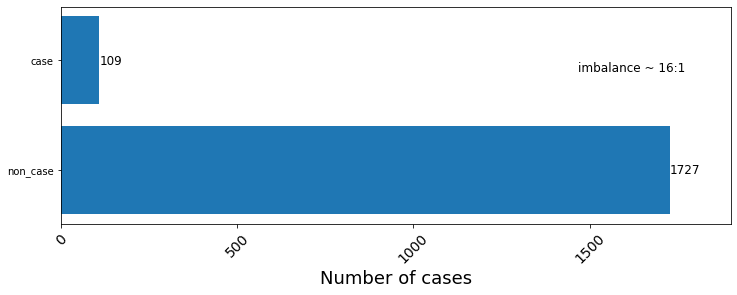

In [18]:
plot_imbalance(dataset)

In [19]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [20]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:6 || ##
Year: 2011 || w0:1, w1:7 || ##
Year: 2018 || w0:1, w1:6 || ##
Year: 2019 || w0:1, w1:10 || ##
Year: 2020 || w0:1, w1:6 || ##
Year: 2021 || w0:1, w1:5 || ##


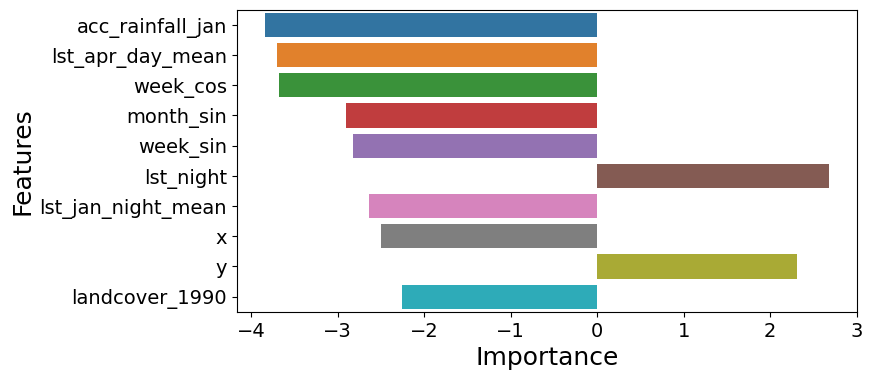

In [21]:
plot_feature_importance(coefficients, feature_names, top = 10, figure_size = (8, 4))

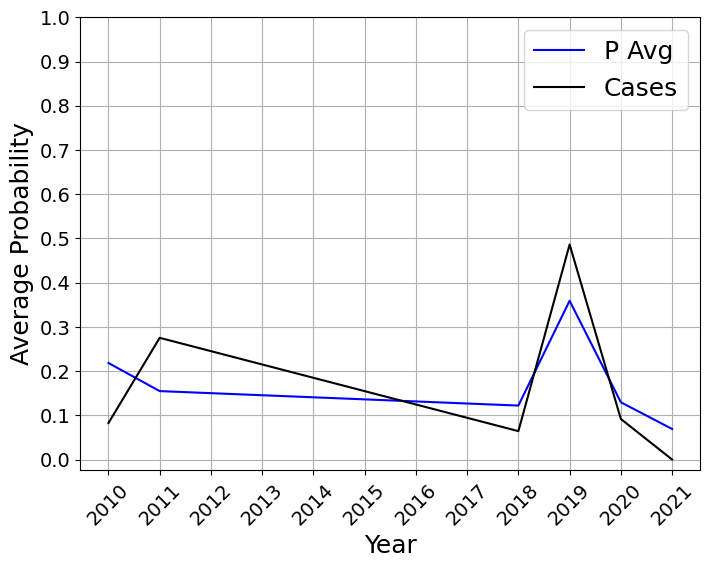

In [22]:
plot_trend_curve(results_test, list(dsc['case']))

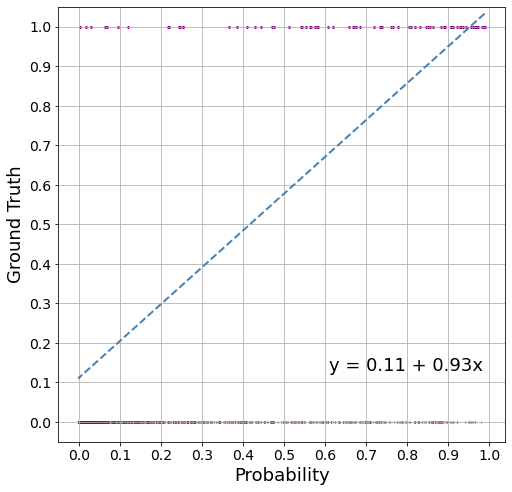

In [23]:
plot_probability_curve(results_test)

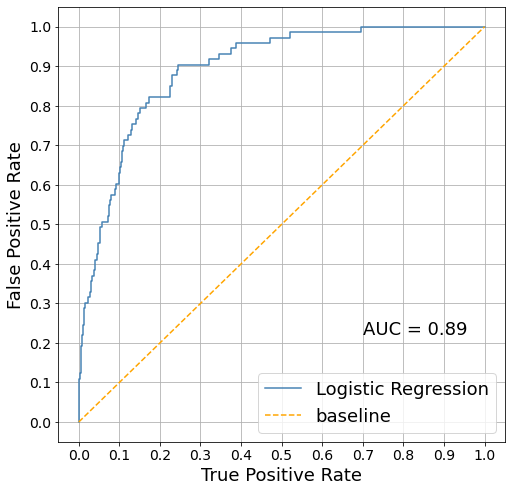

In [24]:
plot_roc_curve(results_test)

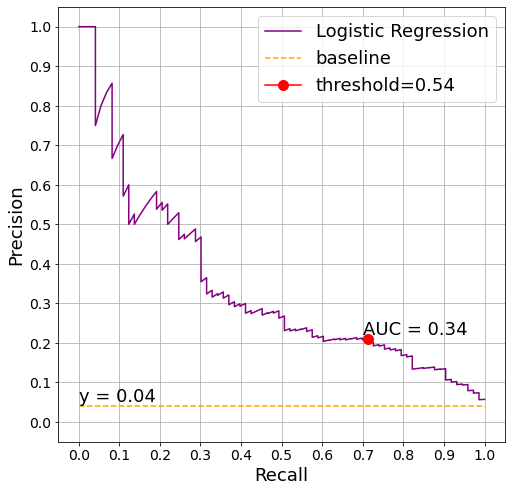

In [25]:
plot_pr_curve(results_test, plot_fbeta = True)

In [26]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 5, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

Average: 47.94%
Weighted Average: nan%


C:\Users/dimit/Desktop/new/Modules\utils.py:465: RuntimeWarning: invalid value encountered in longlong_scalars
  all_percentage = all_discovered/all_outof


In [27]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/05/2010,0,0,0,NaN,NaN
1,16/05/2010,0,0,0,NaN,NaN
2,01/06/2010,0,0,0,NaN,NaN
3,16/06/2010,0,0,0,NaN,NaN
4,01/07/2010,0,0,0,NaN,NaN
...,...,...,...,...,...,...
67,16/08/2021,0,0,0,NaN,NaN
68,01/09/2021,0,0,0,NaN,NaN
69,16/09/2021,0,0,0,NaN,NaN
70,01/10/2021,0,0,0,NaN,NaN


In [28]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2010,6,1,6,16.67 %,0.1667
1,2011,23,10,19,52.63 %,0.5263
2,2018,5,4,5,80.00 %,0.8000
3,2019,30,15,22,68.18 %,0.6818
4,2020,9,2,9,22.22 %,0.2222
5,2021,0,0,0,nan %,NaN


In [29]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1953: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1308: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1953: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1308: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to contro

In [30]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,6.0000,0.3567,0.8282,0.0561,1.0000,0.5025,0.3541
1,2011,23.0000,0.2700,0.8247,0.2469,0.8696,0.7572,0.2307
2,2018,5.0000,0.2133,0.6966,0.0469,0.6000,0.3542,0.2016
3,2019,30.0000,0.5167,0.7685,0.1935,1.0000,0.8031,0.5451
4,2020,9.0000,0.2200,0.7875,0.1061,0.7778,0.5667,0.2175
5,2021,0.0000,0.1067,0.8933,0.0000,0.0000,0.0000,0.0910
6,Mean,12.1667,0.2806,0.7998,0.1082,0.7079,0.4973,0.2733
